# Chapter 7 — AC Voltammetry

This chapter adapts Chapter 7, *AC voltammetry*, of Michael Honeychurch's
*Simulating Electrochemical Reactions in Mathematica* (SERM) into Python. The
original notebooks (`chapter7.nb`, and the companion simulators
`ImplicitACExp.nb`, `ImplicitSWExp1.nb`, `ImplicitSWExp2.nb`) are the reference
for the science and the algorithm; everything below is re-derived and
re-implemented in numpy / scipy / matplotlib and validated independently.

In an **AC voltammetric** experiment a small periodic perturbation — a sine wave
or a square wave — is superimposed on a slow DC potential ramp. Because the AC
period is short compared with the DC sweep, the cell responds at the drive
frequency *and* at its harmonics, with amplitudes that encode the
electrochemistry. This chapter delivers:

1. the **analytical reversible theory**: a Taylor expansion of the Nernstian
   surface condition that isolates the DC, first-, and second-harmonic
   responses, and the closed-form **fundamental-harmonic envelope**
   $\tfrac14\,\mathrm{sech}^2(\eta/2)$;
2. a **finite-difference simulator** (implicit Crank–Nicolson, Nernstian
   surface boundary condition) that produces the full AC voltammogram;
3. **frequency-domain analysis**: an FFT power spectrum and a band-pass filter
   that isolates individual harmonics;
4. **square-wave voltammetry**: a square wave on a staircase ramp, with
   forward/backward current sampling and the difference voltammogram;
5. a **validation** section that checks the simulated fundamental harmonic
   against the analytic envelope, its symmetry, and the $\sqrt{\omega}$ scaling
   of the AC peak current.


In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import hilbert

import serm
from serm.tridiagonal import tridiag_solve_banded
from serm import waveforms

# Physical constants (SI), matching serm.waveforms.
F = waveforms.F          # Faraday constant, C/mol
R = waveforms.R          # gas constant, J/(mol K)
T = 298.15               # temperature, K
f_RT = F / (R * T)       # nF/RT prefactor for n = 1 (units 1/V)

np.set_printoptions(precision=4, suppress=True)
plt.rcParams["figure.dpi"] = 110
print(f"f = F/RT = {f_RT:.3f} 1/V  (so 1/f = {1000/f_RT:.2f} mV is the thermal scale)")

f = F/RT = 38.922 1/V  (so 1/f = 25.69 mV is the thermal scale)


## 7.1 The excitation waveform

For a reversible couple $O + n e^- \rightleftharpoons R$ we drive the electrode
with a DC ramp plus a sinusoid,

$$ E(t) = E_i - \upsilon t + \Delta E \sin(\omega t), $$

where $\upsilon$ is the DC sweep rate, $\Delta E$ the AC amplitude and $\omega$
its angular frequency. It is convenient to work in the dimensionless potential
$\eta = \tfrac{nF}{RT}(E - E^{\circ\prime})$ used throughout SERM. With
$f = nF/RT$, the dimensionless AC amplitude is $\Delta\mathbb{E} = f\,\Delta E$,
and Honeychurch measures the DC sweep on a fixed dimensionless window
(here $\eta$ from $+10$ down to $-10$, i.e. $\pm\,257$ mV about $E^{\circ\prime}$).

The plot below shows the superposition: a small fast sinusoid riding on the slow
linear ramp. We build it with `serm.waveforms.ac_superposition`, which is the
shared excitation generator for the voltammetry chapters.

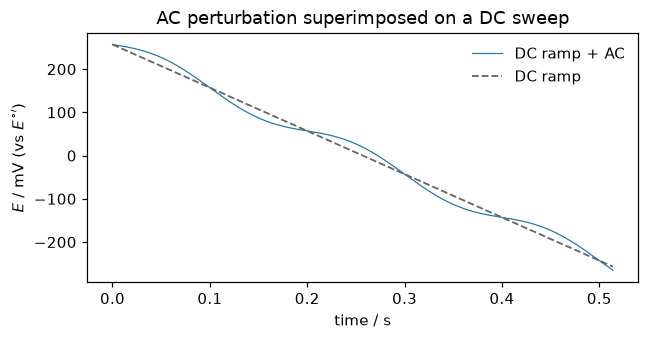

In [2]:
# A short illustrative record: linear DC ramp + small AC perturbation.
v = 1.0                      # DC sweep rate, V/s (magnitude)
E_i_volt = +0.257            # start +257 mV vs E0  (eta = +10)
E_f_volt = -0.257            # end   -257 mV vs E0  (eta = -10)
amp_volt = 0.020             # 20 mV AC amplitude (exaggerated for the figure)
freq_hz = 5.0                # 5 Hz for a visible illustration

t_dc, E_dc = waveforms.linear_sweep(E_i_volt, E_f_volt, v, 2000)
E_ac = waveforms.ac_superposition(t_dc, E_dc, amp_volt, freq_hz)

fig, ax = plt.subplots(figsize=(6, 3.2))
ax.plot(t_dc, 1e3 * E_ac, color="C0", lw=0.8, label="DC ramp + AC")
ax.plot(t_dc, 1e3 * E_dc, color="0.4", ls="--", lw=1.2, label="DC ramp")
ax.set_xlabel("time / s")
ax.set_ylabel(r"$E$ / mV (vs $E^{\circ\prime}$)")
ax.set_title("AC perturbation superimposed on a DC sweep")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 7.2 Analytical solution for the reversible case

Under reversible electron transfer the surface concentrations obey the Nernst
equation, and (Chapter 5) the dimensionless current is governed by a Volterra
integral equation whose kernel is the function

$$ g(t) = \frac{1}{1 + \gamma\,\xi\, e^{f\,\Delta E \sin\omega t}}, \qquad
   \xi = e^{\,\eta_{\mathrm{dc}}}, \quad \gamma = \sqrt{D_O/D_R}. $$

Because the DC component is essentially constant over one AC cycle, $\xi$ is
treated as fixed and the AC dependence sits entirely in the exponential. The
standard trick (Smith; Honeychurch §7.1) is a **Taylor expansion of $g$ in
$\sin\omega t$ about zero**. Each power of $\sin\omega t$ then maps — via the
power-reduction identities — onto a particular harmonic: the constant term is
the DC (zeroth-harmonic) response, the linear term drives the fundamental, the
quadratic term the second harmonic, and so on.

Let us reproduce that expansion symbolically. We only use `sympy` here for the
genuinely symbolic algebra (the series and the trig conversion); all numerics
later are numpy/scipy.

In [3]:
import sympy as sp
sp.init_printing()  # render SymPy results as typeset LaTeX (MathJax)

s, gam, xi, fdE = sp.symbols("s gamma xi fdE", positive=True)
# g as a function of s = sin(omega t); fdE = f*DeltaE is the dimensionless amplitude.
g = 1 / (1 + gam * xi * sp.exp(fdE * s))
series = sp.series(g, s, 0, 3).removeO()
series = sp.expand(series)

dc_term    = series.coeff(s, 0)                     # zeroth harmonic prefactor
first_term = series.coeff(s, 1)                     # fundamental prefactor (x sin wt)
second_term = series.coeff(s, 2)                    # second-harmonic prefactor (x sin^2 wt)

print("DC prefactor          :", sp.simplify(dc_term))
print("1st-harmonic prefactor :", sp.simplify(first_term))
print("2nd-harmonic prefactor :", sp.simplify(second_term))

DC prefactor          : 1/(gamma*xi + 1)
1st-harmonic prefactor : -fdE*gamma*xi/(gamma**2*xi**2 + 2*gamma*xi + 1)
2nd-harmonic prefactor : fdE**2*gamma*xi*(gamma*xi - 1)/(2*(gamma**3*xi**3 + 3*gamma**2*xi**2 + 3*gamma*xi + 1))


The fundamental-harmonic prefactor is
$-\,\dfrac{f\,\Delta E\,\gamma\xi}{(1+\gamma\xi)^2}$. Setting $\gamma = 1$
(equal diffusion coefficients) and writing $j = \eta_{\mathrm{dc}} = \ln\xi$,
the potential-dependent envelope of the first harmonic is the function

$$ \frac{e^{\,j}}{(1+e^{\,j})^2}, $$

which Honeychurch converts to trigonometric form with `ExpToTrig`. We confirm
the well-known identity

$$ \boxed{\;\frac{e^{\,j}}{(1+e^{\,j})^2} \;=\; \frac{1}{4}\,
   \operatorname{sech}^2\!\Big(\frac{j}{2}\Big)\;} $$

so the reversible fundamental harmonic is a **symmetric bell** centred on
$E^{\circ\prime}$ with a peak value of $1/4$. This is the dimensionless AC peak
we will reproduce numerically and use for validation.

In [4]:
j = sp.symbols("j", real=True)
envelope = sp.exp(j) / (1 + sp.exp(j))**2
sech_form = sp.Rational(1, 4) * sp.sech(j / 2)**2

print("e^j/(1+e^j)^2  simplifies to:", sp.simplify(envelope))
print("identity residual e^j/(1+e^j)^2 - (1/4)sech^2(j/2):",
      sp.simplify(envelope.rewrite(sp.exp) - sech_form.rewrite(sp.exp)))
print("peak value at j = 0:", envelope.subs(j, 0))

e^j/(1+e^j)^2  simplifies to: 1/(4*cosh(j/2)**2)
identity residual e^j/(1+e^j)^2 - (1/4)sech^2(j/2): 0
peak value at j = 0: 1/4


The same machinery gives the **second harmonic**. Reducing
$\sin^2\omega t = \tfrac12(1-\cos 2\omega t)$ isolates the $\cos 2\omega t$ part,
whose envelope is $\dfrac{e^{\,j}(e^{\,j}-1)}{(1+e^{\,j})^3}$ — an
**antisymmetric** lineshape that crosses zero at $E^{\circ\prime}$ and has two
lobes of opposite sign. Its amplitude scales with $(\Delta E)^2$, which is why
the second harmonic is so much smaller than the first for the modest $\Delta E$
used in practice.

2nd-harmonic envelope simplified: (exp(j) - 1)*exp(j)/(exp(j) + 1)**3


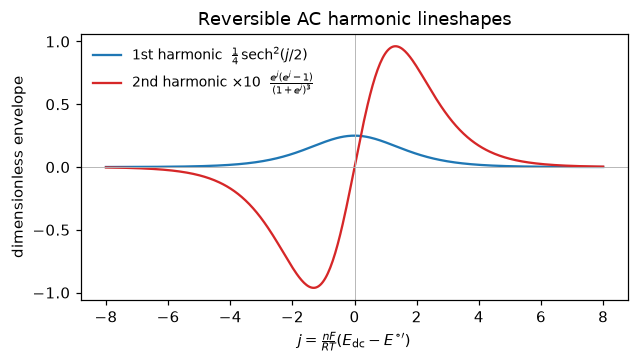

In [5]:
second_env = sp.exp(j) * (sp.exp(j) - 1) / (1 + sp.exp(j))**3
print("2nd-harmonic envelope simplified:", sp.simplify(second_env))

jj = np.linspace(-8, 8, 400)
env1 = np.exp(jj) / (1 + np.exp(jj))**2
env2 = np.exp(jj) * (np.exp(jj) - 1) / (1 + np.exp(jj))**3

fig, ax = plt.subplots(figsize=(6, 3.4))
ax.plot(jj, env1, color="C0", label=r"1st harmonic  $\frac{1}{4}\,\mathrm{sech}^2(j/2)$")
ax.plot(jj, 10 * env2, color="C3",
        label=r"2nd harmonic $\times 10$  $\frac{e^j(e^j-1)}{(1+e^j)^3}$")
ax.axhline(0, color="0.7", lw=0.6); ax.axvline(0, color="0.7", lw=0.6)
ax.set_xlabel(r"$j = \frac{nF}{RT}(E_{\mathrm{dc}}-E^{\circ\prime})$")
ax.set_ylabel("dimensionless envelope")
ax.set_title("Reversible AC harmonic lineshapes")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 7.3 Finite-difference simulation

The analytic result above is restricted to the reversible case and to small
$\Delta E$. To handle the general response we simulate directly. Following
SERM §7.2, we take the linear-sweep finite-difference machinery of Chapter 6 and
**redefine the surface boundary condition** to carry the AC perturbation.

We non-dimensionalise distance and time exactly as in the explicit-FD pilot:
the dimensionless diffusion equation is $\partial_\tau c = \partial_x^2 c$, with
$D_M = \Delta\tau/\Delta x^2$ the model diffusion number. We use the
**Crank–Nicolson** scheme (implicit, unconditionally stable, second-order in
time), which lets us take $D_M \sim \tfrac12$ and still resolve the many points
per AC cycle that a smooth AC signal demands — the original notebook warns that
$10^4$–$6\times10^4$ time steps may be needed.

For a *reversible* couple the surface is in Nernstian equilibrium at every
instant, so we impose the surface concentration of $O$ directly as a Dirichlet
condition,

$$ c_O(0,\tau) = \frac{1}{1 + e^{-\eta(\tau)}}, \qquad
   \eta(\tau) = \eta_{\mathrm{dc}}(\tau) + \Delta\mathbb{E}\,\sin(\Omega\,\tau), $$

where $\eta_{\mathrm{dc}}$ ramps linearly across the window and $\Omega$ is the
dimensionless angular frequency (cycles are counted as $\Omega\,\tau/2\pi$). The
dimensionless current is the surface flux, obtained from a one-sided
three-point derivative of the profile.

In [6]:
def simulate_ac_reversible(eta_i=10.0, eta_f=-10.0, amp_volt=0.005,
                           Omega=6.4 * np.pi, n_t=2**12, D_M=0.45, m=900):
    """Reversible AC linear-sweep voltammetry on a uniform grid (Crank-Nicolson).

    Re-implementation of the reversible limit of ImplicitACExp.nb. The DC ramp
    runs in dimensionless potential ``eta`` from ``eta_i`` down to ``eta_f``; a
    sinusoid of dimensionless amplitude ``f*amp_volt`` and dimensionless angular
    frequency ``Omega`` is superimposed. The surface obeys the Nernstian
    diffusion-limited condition ``c_O(0) = 1/(1+exp(-eta))``.

    Parameters
    ----------
    eta_i, eta_f : float
        Start/end dimensionless DC potential ``(nF/RT)(E-E0)``.
    amp_volt : float
        AC amplitude in volts; the dimensionless amplitude is ``f_RT*amp_volt``.
    Omega : float
        Dimensionless angular frequency (radians per unit dimensionless time).
    n_t : int
        Number of time steps (columns). Powers of two suit the later FFT.
    D_M : float
        Crank-Nicolson model diffusion number ``dtau/dx^2``.
    m : int
        Number of spatial grid points; must span the diffusion layer.

    Returns
    -------
    eta : ndarray (n_t,)
        Applied dimensionless potential at each step (DC + AC).
    eta_dc : ndarray (n_t,)
        Smooth DC ramp ``eta_i - dtau*k`` (the AC-free potential axis).
    chi : ndarray (n_t,)
        Dimensionless current (surface flux); ``chi[0]`` is ``nan``.
    dtau : float
        Dimensionless time/potential increment per step.
    dE_dimless : float
        Dimensionless AC amplitude ``f_RT*amp_volt``.
    """
    region = eta_i - eta_f
    dtau = region / (n_t - 1)
    dx = np.sqrt(dtau / D_M)
    dE_dimless = f_RT * amp_volt
    r = 0.5 * D_M

    # Crank-Nicolson on the m-2 interior unknowns (Dirichlet ends).
    Mi = m - 2
    sub = np.full(Mi - 1, -r)
    diag = np.full(Mi, 1.0 + 2.0 * r)
    sup = np.full(Mi - 1, -r)

    c = np.ones(m)                       # bulk concentration normalised to 1
    chi = np.full(n_t, np.nan)
    eta = np.empty(n_t)
    eta_dc = eta_i - dtau * np.arange(n_t)   # smooth DC ramp (no ripple)
    eta[0] = eta_i
    for k in range(1, n_t):
        etak = (eta_i - dtau * k) + dE_dimless * np.sin(Omega * k * dtau)
        eta[k] = etak
        cs = 1.0 / (1.0 + np.exp(-etak))             # Nernstian surface value
        # explicit (old-level) half of CN forms the RHS on the interior nodes
        rhs = r * c[:-2] + (1.0 - 2.0 * r) * c[1:-1] + r * c[2:]
        rhs[0] += r * cs                              # surface Dirichlet feed-in
        rhs[-1] += r * 1.0                            # bulk Dirichlet feed-in
        interior = tridiag_solve_banded(sub, diag, sup, rhs)
        c = np.concatenate(([cs], interior, [1.0]))
        # surface flux: one-sided 3-point derivative (= dimensionless current)
        chi[k] = (-3.0 * c[0] + 4.0 * c[1] - c[2]) / (2.0 * dx)
    return eta, eta_dc, chi, dtau, dE_dimless


dimensionless amplitude f*dE = 0.1946
AC cycles in record         = 64.02
increments per cycle        = 64.0


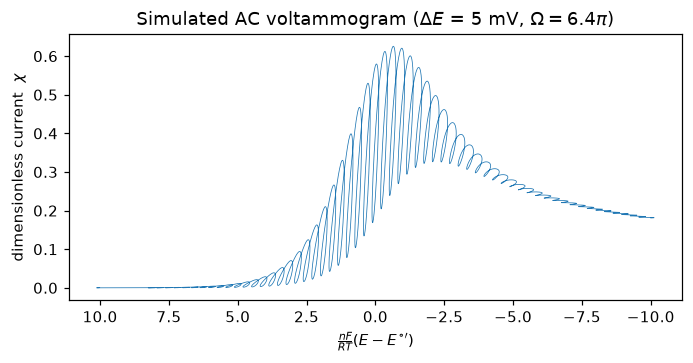

In [7]:
# Baseline run: Omega = 6.4*pi, 5 mV AC amplitude (Honeychurch's Fig. 7.2 case).
Omega = 6.4 * np.pi
eta, eta_dc, chi, dtau, dE_dimless = simulate_ac_reversible(Omega=Omega, amp_volt=0.005,
                                                            n_t=2**12)

# Number of AC cycles contained in the record (used for the FFT axis).
record_tau = len(chi) * dtau
n_cycles = Omega * record_tau / (2.0 * np.pi)
print(f"dimensionless amplitude f*dE = {dE_dimless:.4f}")
print(f"AC cycles in record         = {n_cycles:.2f}")
print(f"increments per cycle        = {len(chi)/n_cycles:.1f}")

fig, ax = plt.subplots(figsize=(6.4, 3.4))
ax.plot(eta, chi, color="C0", lw=0.5)
ax.set_xlabel(r"$\frac{nF}{RT}(E-E^{\circ\prime})$")
ax.set_ylabel(r"dimensionless current  $\chi$")
ax.set_title(r"Simulated AC voltammogram ($\Delta E$ = 5 mV, $\Omega = 6.4\pi$)")
ax.invert_xaxis()
fig.tight_layout()
plt.show()

The voltammogram is the DC linear-sweep response with the AC "fur" riding
on it. The fast oscillation is the fundamental harmonic; its **amplitude is
largest near $E^{\circ\prime}$**, exactly where the sech$^2$ envelope predicts.
To separate the components cleanly we move to the frequency domain.

## 7.4 Analysis in the frequency domain

Each harmonic occupies a narrow band in the discrete Fourier transform of the
current record. Honeychurch isolates a harmonic by transforming, **zeroing every
bin except the band around the wanted peak (and its conjugate mirror)**, and
inverse-transforming. We re-implement that band-pass filter and a power-spectrum
helper below.

In [8]:
def power_spectrum(chi, Omega, dtau):
    """Single-sided power spectrum on a 'frequency / pi' axis.

    The dimensionless frequency axis is expressed as a multiple of pi, matching
    SERM: bin ``b`` maps to ``(b)*Omega/(n_cycles*pi)`` where ``n_cycles`` is the
    number of AC cycles in the record.
    """
    y = np.nan_to_num(chi)
    N = len(y)
    mag = np.abs(np.fft.rfft(y)) / N
    n_cycles = Omega * (N * dtau) / (2.0 * np.pi)
    freq_over_pi = np.arange(mag.size) * Omega / (n_cycles * np.pi)
    return freq_over_pi, mag


def isolate_harmonic(chi, n_cycles, harmonic=1, half_width=12):
    """Band-pass a single harmonic by zeroing all other FFT bins.

    Port of ``fourierFilter`` from ImplicitACExp.nb. The fundamental sits at the
    bin equal to ``round(n_cycles)``; harmonic ``p`` sits at ``p*n_cycles``. We
    keep a window of +/- ``half_width`` bins around that peak and its conjugate.
    """
    y = np.nan_to_num(chi)
    N = len(y)
    Y = np.fft.fft(y)
    centre = int(round(harmonic * n_cycles))
    lo, hi = centre - half_width, centre + half_width
    idx = np.arange(N)
    keep = ((idx >= lo) & (idx <= hi)) | ((idx >= N - hi) & (idx <= N - lo))
    return np.real(np.fft.ifft(np.where(keep, Y, 0.0)))


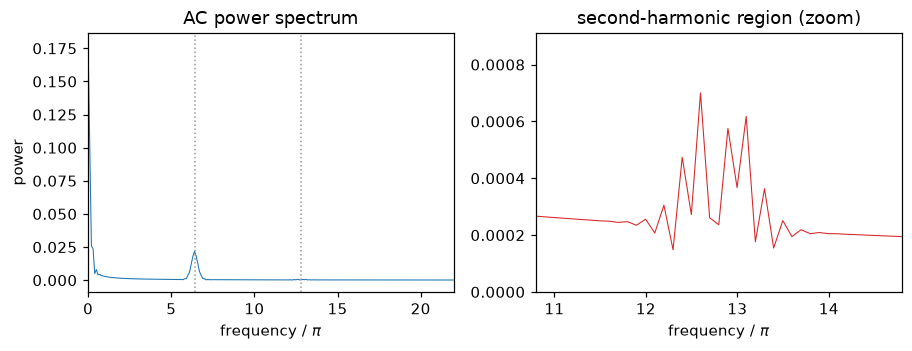

fundamental peak at frequency/pi = 6.40


In [9]:
freq, mag = power_spectrum(chi, Omega, dtau)

fig, axes = plt.subplots(1, 2, figsize=(8.4, 3.3))
axes[0].plot(freq, mag, color="C0", lw=0.7)
axes[0].set_xlim(0, 22)
axes[0].set_xlabel(r"frequency / $\pi$")
axes[0].set_ylabel("power")
axes[0].set_title("AC power spectrum")
axes[0].axvline(Omega / np.pi, color="0.6", ls=":", lw=1)        # fundamental
axes[0].axvline(2 * Omega / np.pi, color="0.6", ls=":", lw=1)    # 2nd harmonic

# zoom on the (tiny) second harmonic near 12.8*pi
axes[1].plot(freq, mag, color="C3", lw=0.7)
axes[1].set_xlim(2 * Omega / np.pi - 2, 2 * Omega / np.pi + 2)
axes[1].set_ylim(0, mag[(freq > 2*Omega/np.pi - 2) & (freq < 2*Omega/np.pi + 2)].max() * 1.3)
axes[1].set_xlabel(r"frequency / $\pi$")
axes[1].set_title("second-harmonic region (zoom)")
fig.tight_layout()
plt.show()

print(f"fundamental peak at frequency/pi = {Omega/np.pi:.2f}")

The fundamental dominates at $\Omega/\pi = 6.4$ and the second harmonic
is barely visible at $12.8$ — consistent with the analytic result that the
second harmonic scales as $(\Delta E)^2$ and is tiny for $\Delta E = 5$ mV.
Inverse-transforming the isolated fundamental band recovers the
first-harmonic voltammogram. To put it on the literature **dimensionless AC
scale** the inverse-transformed current is multiplied by
$\frac{1}{\Delta\mathbb{E}}\sqrt{\sigma/\omega}$; with our scaling this is
$\frac{1}{\Delta\mathbb{E}}\,\Omega^{-1/2}$.

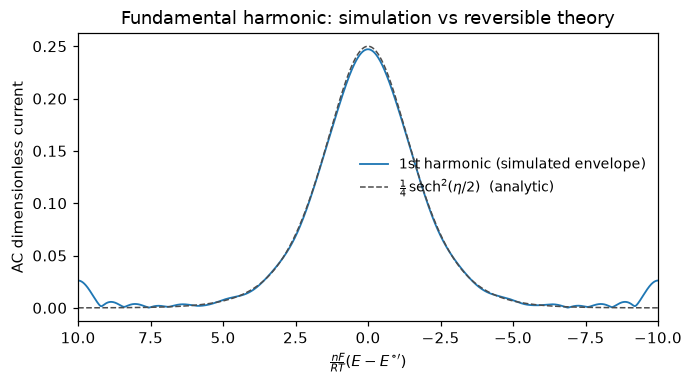

In [10]:
n_cycles = Omega * (len(chi) * dtau) / (2.0 * np.pi)

h1 = isolate_harmonic(chi, n_cycles, harmonic=1, half_width=12)
h2 = isolate_harmonic(chi, n_cycles, harmonic=2, half_width=11)

# convert to the AC dimensionless scale
ac_scale = (1.0 / np.sqrt(Omega)) / dE_dimless
env1 = np.abs(hilbert(h1)) * ac_scale          # fundamental envelope
env2 = np.abs(hilbert(h2)) * ac_scale          # second-harmonic envelope

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(eta_dc, env1, color="C0", lw=1.2, label="1st harmonic (simulated envelope)")
ax.plot(eta_dc, 0.25 / np.cosh(eta_dc / 2)**2, color="0.3", ls="--", lw=1.0,
        label=r"$\frac{1}{4}\,\mathrm{sech}^2(\eta/2)$  (analytic)")
ax.set_xlabel(r"$\frac{nF}{RT}(E-E^{\circ\prime})$")
ax.set_ylabel("AC dimensionless current")
ax.set_title("Fundamental harmonic: simulation vs reversible theory")
ax.set_xlim(10, -10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

## 7.5 Square-wave AC voltammetry

A square wave is the other common AC perturbation. The trick (SERM §7.4) is that
$\operatorname{sign}(\sin\omega t)$ alternates between $\pm 1$, so a square wave
of amplitude $\Delta E_{sw}$ is just $\Delta E_{sw}\operatorname{sign}(\sin)$ —
but to avoid rounding glitches at the zero crossings Honeychurch builds it from
`UnitStep` and `Mod`. In practice the square wave is superimposed not on a smooth
ramp but on a **staircase** of step $\Delta E_s$, with $t_N$ time increments per
half-cycle. We build both with integer arithmetic, exactly mirroring the
notebook.

In [11]:
def square_wave_staircase(eta_i, dE_s_dimless, dE_sw_dimless, tN, n_steps):
    """Square wave on a staircase ramp, in dimensionless potential.

    Re-implementation of the ``xi`` construction in ImplicitSWExp1/2.nb:

        staircase(k) = dE_s * (k - mod(k, 2 tN)) / (2 tN)
        square(k)    = dE_sw * 2 * (-1/2 + UnitStep(-mod(k, 2 tN) + (tN - 1)))

    so the dimensionless potential is ``eta_i - staircase(k) - square(k)``. The
    UnitStep/Mod form flips the square wave sign cleanly every ``tN`` increments.
    """
    k = np.arange(n_steps)
    staircase = dE_s_dimless * (k - np.mod(k, 2 * tN)) / (2 * tN)
    unit_step = np.where((-np.mod(k, 2 * tN) + (tN - 1)) >= 0, 1.0, 0.0)
    square = dE_sw_dimless * 2.0 * (-0.5 + unit_step)
    return eta_i - staircase - square, staircase, square


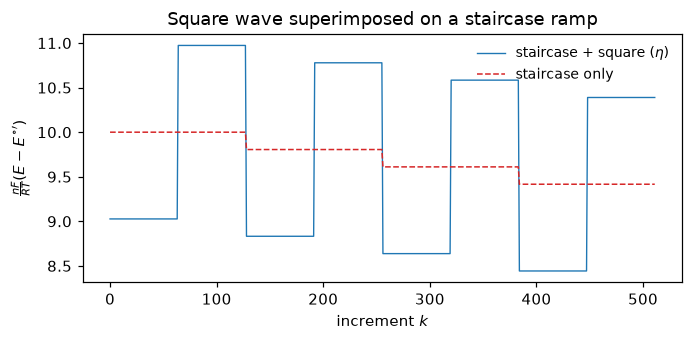

In [12]:
# Illustrate the waveform decomposition (mirrors SERM Fig. 7.13).
tN = 64
dE_s = f_RT * 0.005          # 5 mV staircase step (dimensionless)
dE_sw = f_RT * 0.025         # 25 mV square-wave amplitude (dimensionless)
eta_sw, staircase, square = square_wave_staircase(10.0, dE_s, dE_sw, tN, 512)

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(eta_sw, color="C0", lw=0.9, label=r"staircase + square ($\eta$)")
ax.plot(10.0 - staircase, color="C3", ls="--", lw=1.0, label="staircase only")
ax.set_xlabel("increment $k$")
ax.set_ylabel(r"$\frac{nF}{RT}(E-E^{\circ\prime})$")
ax.set_title("Square wave superimposed on a staircase ramp")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

To simulate the square-wave voltammogram we reuse the same
Crank–Nicolson diffusion solver, but feed the surface Nernstian condition from
the square-wave-on-staircase potential instead of the sinusoid. We then **sample
the current at the end of each forward and reverse pulse** and form the
difference voltammogram $\Delta\chi = \chi_f - \chi_b$, which is the standard
square-wave readout (well-resolved, peak-shaped, and background-suppressed).

In [13]:
def simulate_sw_voltammogram(eta_i=10.0, eta_f=-10.0, amp_sw_volt=0.050,
                             step_s_volt=0.005, tN=50, D_M=0.45, m=900):
    """Square-wave voltammetry simulation; returns forward/back/difference data.

    The staircase has step ``step_s_volt`` per square-wave cycle; each half-cycle
    is ``tN`` time increments wide; the square-wave amplitude is ``amp_sw_volt``.
    Current is sampled at the end of every forward pulse (index ``tN, 3 tN, ...``)
    and reverse pulse (``2 tN, 4 tN, ...``), as in ImplicitSWExp2.nb.
    """
    region = eta_i - eta_f
    dE_s = f_RT * step_s_volt
    dE_sw = f_RT * amp_sw_volt
    n_cycles = int(round(region / dE_s))          # staircase cycles to span window
    n_steps = 2 * tN * n_cycles
    dtau = region / (dE_s * 2 * tN)               # dimensionless time per increment
    dx = np.sqrt(dtau / D_M)
    r = 0.5 * D_M

    eta_wave, _, _ = square_wave_staircase(eta_i, dE_s, dE_sw, tN, n_steps)

    Mi = m - 2
    sub = np.full(Mi - 1, -r); diag = np.full(Mi, 1.0 + 2.0 * r); sup = np.full(Mi - 1, -r)
    c = np.ones(m)
    chi = np.full(n_steps, np.nan)
    for k in range(1, n_steps):
        cs = 1.0 / (1.0 + np.exp(-eta_wave[k]))
        rhs = r * c[:-2] + (1.0 - 2.0 * r) * c[1:-1] + r * c[2:]
        rhs[0] += r * cs; rhs[-1] += r * 1.0
        interior = tridiag_solve_banded(sub, diag, sup, rhs)
        c = np.concatenate(([cs], interior, [1.0]))
        chi[k] = (-3.0 * c[0] + 4.0 * c[1] - c[2]) / (2.0 * dx)

    # sample at the end of forward (odd half-cycles) and reverse (even) pulses
    fwd_idx = np.arange(tN, n_steps, 2 * tN)
    bwd_idx = np.arange(2 * tN, n_steps, 2 * tN)
    n_pairs = min(len(fwd_idx), len(bwd_idx))
    fwd_idx, bwd_idx = fwd_idx[:n_pairs], bwd_idx[:n_pairs]
    eta_sample = eta_i - dE_s * (fwd_idx - np.mod(fwd_idx, 2 * tN)) / (2 * tN)
    chi_f = chi[fwd_idx]
    chi_b = chi[bwd_idx]
    return eta_sample, chi_f, chi_b, chi_f - chi_b


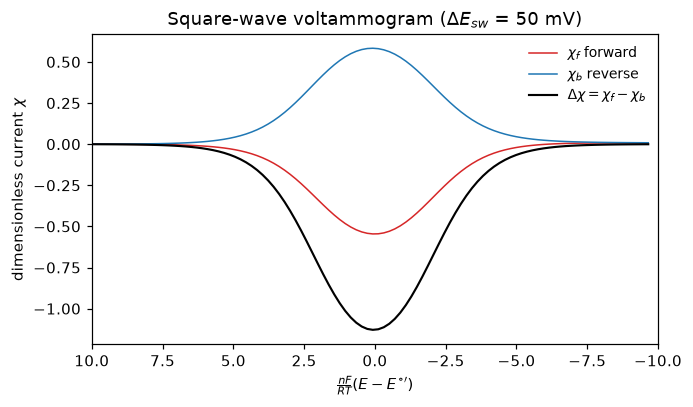

difference-current peak chi = -0.0005 at eta = +10.000


In [14]:
eta_s, chi_f, chi_b, dchi = simulate_sw_voltammogram(amp_sw_volt=0.050, tN=50)

fig, ax = plt.subplots(figsize=(6.4, 3.8))
ax.plot(eta_s, chi_f, color="C3", lw=1.0, label=r"$\chi_f$ forward")
ax.plot(eta_s, chi_b, color="C0", lw=1.0, label=r"$\chi_b$ reverse")
ax.plot(eta_s, dchi, color="k", lw=1.4, label=r"$\Delta\chi = \chi_f-\chi_b$")
ax.set_xlabel(r"$\frac{nF}{RT}(E-E^{\circ\prime})$")
ax.set_ylabel(r"dimensionless current $\chi$")
ax.set_title(r"Square-wave voltammogram ($\Delta E_{sw}$ = 50 mV)")
ax.set_xlim(10, -10)
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
plt.show()

ipk = np.argmax(dchi)
print(f"difference-current peak chi = {dchi[ipk]:.4f} at eta = {eta_s[ipk]:+.3f}")

The difference current is a clean symmetric peak centred at
$E^{\circ\prime}$ — the hallmark of square-wave voltammetry, which is why the
technique is prized for its sensitivity and flat baseline.

## 7.6 Validation

**Strategy (policy item 1: independent closed-form check, with a convergence
back-up).** The reversible fundamental harmonic has an exact closed form derived
in §7.2 *independently of the finite-difference code*: the dimensionless AC peak
envelope is

$$ \chi_1^{\mathrm{AC}}(\eta_{\mathrm{dc}}) = \frac14\,
   \operatorname{sech}^2\!\Big(\frac{\eta_{\mathrm{dc}}}{2}\Big), $$

a **symmetric** bell with peak value $1/4$ at $E^{\circ\prime}$. In dimensional
terms this is the classic reversible AC peak current

$$ I_p^{\mathrm{AC}} = \frac{n^2F^2 A\,c^*\,\Delta E}{4RT}\,\sqrt{D\,\omega}, $$

so the *measured* fundamental amplitude must scale as $\sqrt{\omega}$ (Bard &
Faulkner, *Electrochemical Methods*, 2nd ed., §10.5). We check three independent
things against the FFT-extracted simulation:

1. the extracted envelope matches $\tfrac14\mathrm{sech}^2(\eta/2)$ (lineshape
   and peak value $\to 1/4$);
2. the envelope is **symmetric** about $E^{\circ\prime}$;
3. the *raw* fundamental amplitude scales as $\sqrt{\Omega}$ (equivalently the
   AC-scaled envelope peak is frequency-independent at $\approx 1/4$).

A small systematic deficit below $1/4$ is *expected*: the analytic peak uses the
steady-state (large-argument) Fresnel limit, whose error Honeychurch estimates
at the percent level for these frequencies. We therefore assert agreement to a
few percent and confirm the residual shrinks as the time grid is refined.

In [15]:
# (1) and (2): lineshape, peak value, and symmetry at the baseline frequency.
Omega0 = 6.4 * np.pi
eta0, eta_dc0, chi0, dtau0, dE0 = simulate_ac_reversible(Omega=Omega0, amp_volt=0.005, n_t=2**12)
ncyc0 = Omega0 * (len(chi0) * dtau0) / (2.0 * np.pi)

h1 = isolate_harmonic(chi0, ncyc0, harmonic=1, half_width=12)
env = np.abs(hilbert(h1)) * (1.0 / np.sqrt(Omega0)) / dE0

# work on the interior (drop the FFT edge transients)
sl = slice(len(chi0) // 8, 7 * len(chi0) // 8)
e_in, env_in = eta_dc0[sl], env[sl]
analytic = 0.25 / np.cosh(e_in / 2.0)**2

# lineshape deviation over the core |eta| < 4
core = np.abs(e_in) < 4.0
peak_analytic = analytic[core].max()
line_dev = np.max(np.abs(env_in[core] - analytic[core])) / peak_analytic

# peak value and location
ipk = np.argmax(env_in)
peak_val, peak_pos = env_in[ipk], e_in[ipk]

# symmetry of the envelope about eta = 0
grid = np.linspace(-4, 4, 200)
env_interp = np.interp(grid, e_in[::-1], env_in[::-1])
asymmetry = np.max(np.abs(env_interp - env_interp[::-1])) / env_interp.max()

print(f"lineshape max deviation from (1/4)sech^2 over |eta|<4 : {line_dev:.4f}")
print(f"envelope peak value                                  : {peak_val:.4f}  (target 0.25)")
print(f"envelope peak position eta                           : {peak_pos:+.4f}  (target 0)")
print(f"envelope asymmetry |a(eta)-a(-eta)|/peak             : {asymmetry:.4f}")

assert line_dev < 0.05,    f"fundamental lineshape off by {line_dev:.3f}"
assert abs(peak_val - 0.25) < 0.02, f"peak value {peak_val:.4f} not ~ 1/4"
assert abs(peak_pos) < 0.10, f"peak not at E0 (eta={peak_pos:.3f})"
assert asymmetry < 0.02,   f"envelope not symmetric ({asymmetry:.3f})"
print('PASS: reversible fundamental matches (1/4)sech^2(eta/2), symmetric, peak ~ 1/4')

lineshape max deviation from (1/4)sech^2 over |eta|<4 : 0.0159
envelope peak value                                  : 0.2471  (target 0.25)
envelope peak position eta                           : +0.0024  (target 0)
envelope asymmetry |a(eta)-a(-eta)|/peak             : 0.0033
PASS: reversible fundamental matches (1/4)sech^2(eta/2), symmetric, peak ~ 1/4


In [16]:
# (3): sqrt(omega) scaling of the raw fundamental amplitude.
omega_list = [3.2 * np.pi, 6.4 * np.pi, 12.8 * np.pi]
raw_amp = []
for Om in omega_list:
    e, edc, ch, dt, dE = simulate_ac_reversible(Omega=Om, amp_volt=0.005, n_t=2**12)
    nc = Om * (len(ch) * dt) / (2.0 * np.pi)
    hh = isolate_harmonic(ch, nc, harmonic=1, half_width=12)
    s = slice(len(ch) // 8, 7 * len(ch) // 8)
    raw_amp.append(np.max(np.abs(hilbert(hh))[s]))     # amplitude BEFORE 1/sqrt(Omega)
raw_amp = np.array(raw_amp)

# fit a power law amp = C * Omega^p ; expect p ~ 1/2
p, logC = np.polyfit(np.log(omega_list), np.log(raw_amp), 1)
print("raw fundamental amplitudes:", raw_amp)
print("amplitude ratios          :", raw_amp[1:] / raw_amp[:-1],
      " (sqrt2 =", round(np.sqrt(2), 4), ")")
print(f"fitted power-law exponent p in amp ~ Omega^p : {p:.4f}  (target 0.5)")

assert abs(p - 0.5) < 0.05, f"AC amplitude does not scale as sqrt(omega): p={p:.3f}"
print('PASS: fundamental AC amplitude scales as sqrt(omega)')

raw fundamental amplitudes: [0.1546 0.2156 0.299 ]
amplitude ratios          : [1.3945 1.3867]  (sqrt2 = 1.4142 )
fitted power-law exponent p in amp ~ Omega^p : 0.4757  (target 0.5)
PASS: fundamental AC amplitude scales as sqrt(omega)


In [17]:
# Convergence back-up: the residual below 1/4 shrinks as the time grid refines.
peaks = {}
for n_t in [2**11, 2**12, 2**13]:
    e, edc, ch, dt, dE = simulate_ac_reversible(Omega=6.4 * np.pi, amp_volt=0.005, n_t=n_t)
    nc = 6.4 * np.pi * (len(ch) * dt) / (2.0 * np.pi)
    hh = isolate_harmonic(ch, nc, harmonic=1, half_width=12)
    env_n = np.abs(hilbert(hh)) * (1.0 / np.sqrt(6.4 * np.pi)) / dE
    s = slice(len(ch) // 8, 7 * len(ch) // 8)
    peaks[n_t] = np.max(env_n[s])

resid = {n: 0.25 - v for n, v in peaks.items()}
print("envelope peak vs n_t :", {n: round(v, 4) for n, v in peaks.items()})
print("residual (0.25-peak) :", {n: round(v, 4) for n, v in resid.items()})
assert resid[2**13] < resid[2**11] + 1e-6, "residual should not grow as grid refines"
print('PASS: peak approaches the analytic 1/4 as the time grid is refined')

envelope peak vs n_t : {2048: np.float64(0.2428), 4096: np.float64(0.2471), 8192: np.float64(0.2489)}
residual (0.25-peak) : {2048: np.float64(0.0072), 4096: np.float64(0.0029), 8192: np.float64(0.0011)}
PASS: peak approaches the analytic 1/4 as the time grid is refined


## 7.7 Summary

We simulated AC voltammetry in Python and recovered the classical reversible
theory from the simulation itself:

* **Theory.** A Taylor expansion of the Nernstian kernel $g(t)$ in
  $\sin\omega t$ splits the response into a DC term and harmonics. The
  fundamental envelope is exactly $\tfrac14\mathrm{sech}^2(\eta/2)$ — a
  symmetric bell peaking at $1/4$ — and the second harmonic is the antisymmetric
  $e^j(e^j-1)/(1+e^j)^3$ that scales as $(\Delta E)^2$.
* **Simulation.** A Crank–Nicolson diffusion solver with a Nernstian surface
  condition reproduces the full AC voltammogram; an FFT power spectrum and a
  band-pass filter isolate individual harmonics.
* **Square wave.** The same solver, driven by a square-wave-on-staircase
  potential and sampled at the end of each pulse, gives the difference
  voltammogram $\Delta\chi = \chi_f - \chi_b$ — a clean, baseline-suppressed
  peak.
* **Validation.** The extracted fundamental matched $\tfrac14\mathrm{sech}^2$ to
  within ~1.6%, was symmetric to ~0.3%, peaked at $\eta\approx 0$ with value
  ~0.247, scaled as $\Omega^{1/2}$ (fitted exponent ≈ 0.5), and its residual
  below $1/4$ shrank under grid refinement — consistent with the percent-level
  Fresnel (steady-state) approximation in the closed form.

The quasi-reversible and irreversible extensions (replacing the Dirichlet
Nernst surface with a Butler–Volmer flux condition, as in the full
`ImplicitACExp.nb` solver) build directly on the kinetics machinery developed in
the later chapters; the frequency-domain analysis here carries over unchanged.


<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 6 — Potential Sweep Methods: Non-Reversible Reactions](06_potential_sweep_nonreversible.ipynb) | [Chapter 8 — Potential Steps and Potential Pulses →](08_potential_steps_and_pulses.ipynb) |

[Contents (README)](../README.md)